# Talent Intelligence & Skills Gap Analysis
## 02 — Skill Gap & Role Readiness Engine

**Scenario:** NorthStar Digital Services is fictional. All workforce and talent data are synthetic.

### Objectives
1. Compare each employee's current skills with target-role requirements.
2. Calculate skill-level gaps.
3. Build an interpretable **Role Readiness Score**.
4. Rank internal candidates for each target role.
5. Identify the most important upskilling gaps by role and across the workforce.

### Scoring principle
The readiness model uses **skills only**. Performance rating, age, location, potential category, and other personal attributes are **not used** in the score.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)


### 1. Connect to the GitHub repository in Google Colab
Run this cell if the repository is not already cloned in the current Colab session.


In [2]:
REPO_URL = 'https://github.com/mazaheriasad/talent-intelligence-skills-gap-analysis.git'
REPO_NAME = 'talent-intelligence-skills-gap-analysis'

if not Path('/content/' + REPO_NAME).exists():
    !git clone {REPO_URL}

%cd /content/{REPO_NAME}


Cloning into 'talent-intelligence-skills-gap-analysis'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 81 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 221.62 KiB | 2.74 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/talent-intelligence-skills-gap-analysis


### 2. Load project data


In [3]:
DATA_DIR = Path('data/raw')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

employee_master = pd.read_csv(DATA_DIR / 'employee_master.csv')
employee_skills = pd.read_csv(DATA_DIR / 'employee_skills.csv')
target_roles = pd.read_csv(DATA_DIR / 'target_roles.csv')
role_skills = pd.read_csv(DATA_DIR / 'role_skills.csv')

print('Employees:', len(employee_master))
print('Employee skill records:', len(employee_skills))
print('Target roles:', len(target_roles))
print('Role skill requirements:', len(role_skills))


Employees: 600
Employee skill records: 5250
Target roles: 8
Role skill requirements: 86


### 3. Build the employee × role × required-skill matrix
For every employee and every target role, create one row per required skill. Missing employee skills are treated as proficiency `0`.


In [4]:
employees = employee_master[['EmployeeID']].drop_duplicates()
roles = target_roles[['RoleID', 'RoleName']].drop_duplicates()

employee_role = employees.merge(roles, how='cross')

comparison = employee_role.merge(
    role_skills[['RoleID','Skill','RequiredProficiency','ImportanceWeight','Mandatory']],
    on='RoleID',
    how='left'
)

comparison = comparison.merge(
    employee_skills[['EmployeeID','Skill','ProficiencyLevel','MonthsSinceLastUse']],
    on=['EmployeeID','Skill'],
    how='left'
)

comparison['ProficiencyLevel'] = comparison['ProficiencyLevel'].fillna(0)
comparison['MonthsSinceLastUse'] = comparison['MonthsSinceLastUse'].fillna(999)

comparison.head()


,EmployeeID,RoleID,RoleName,Skill,RequiredProficiency,ImportanceWeight,Mandatory,ProficiencyLevel,MonthsSinceLastUse
0,E0001,R001,People Analytics Specialist,People Analytics,4,3,Yes,0.0,999.0
1,E0001,R001,People Analytics Specialist,Power BI,4,3,Yes,1.0,3.0
2,E0001,R001,People Analytics Specialist,DAX,3,2,No,0.0,999.0
3,E0001,R001,People Analytics Specialist,SQL,3,3,Yes,0.0,999.0
4,E0001,R001,People Analytics Specialist,Statistics,3,2,No,0.0,999.0


### 4. Calculate skill attainment and skill gap

`SkillAttainment` is capped at 1.00. Surplus proficiency therefore does not inflate readiness.

`SkillGap = max(RequiredProficiency - CurrentProficiency, 0)`


In [5]:
comparison['SkillAttainment'] = np.minimum(
    comparison['ProficiencyLevel'] / comparison['RequiredProficiency'],
    1.0
)

comparison['SkillGap'] = np.maximum(
    comparison['RequiredProficiency'] - comparison['ProficiencyLevel'],
    0
)

comparison['WeightedAttainment'] = (
    comparison['SkillAttainment'] * comparison['ImportanceWeight']
)

comparison['MeetsRequirement'] = (
    comparison['ProficiencyLevel'] >= comparison['RequiredProficiency']
)

comparison[['EmployeeID','RoleName','Skill','ProficiencyLevel','RequiredProficiency','SkillGap','SkillAttainment']].head(15)


,EmployeeID,RoleName,Skill,ProficiencyLevel,RequiredProficiency,SkillGap,SkillAttainment
0,E0001,People Analytics Specialist,People Analytics,0.0,4,4.0,0.00
1,E0001,People Analytics Specialist,Power BI,1.0,4,3.0,0.25
2,E0001,People Analytics Specialist,DAX,0.0,3,3.0,0.00
3,E0001,People Analytics Specialist,SQL,0.0,3,3.0,0.00
4,E0001,People Analytics Specialist,Statistics,0.0,3,3.0,0.00
5,E0001,People Analytics Specialist,Data Visualization,2.0,4,2.0,0.50
6,E0001,People Analytics Specialist,Data Storytelling,0.0,4,4.0,0.00
7,E0001,People Analytics Specialist,Stakeholder Management,4.0,3,0.0,1.00
8,E0001,People Analytics Specialist,Data Quality,3.0,3,0.0,1.00
9,E0001,People Analytics Specialist,Excel,2.0,4,2.0,0.50


### 5. Role Readiness Score

The score has two transparent components:

- **85% Weighted Skill Readiness:** importance-weighted attainment across all required skills.
- **15% Mandatory Skill Coverage:** percentage of mandatory skills meeting the target proficiency.

This produces a score from 0 to 100.


In [6]:
def role_readiness(group):
    weighted_readiness = (
        group['WeightedAttainment'].sum() / group['ImportanceWeight'].sum()
    ) * 100

    mandatory = group[group['Mandatory'].eq('Yes')]
    mandatory_coverage = (
        mandatory['MeetsRequirement'].mean() * 100
        if len(mandatory) > 0 else 100
    )

    total_gap = group['SkillGap'].sum()
    critical_gap_count = (
        (group['SkillGap'].gt(0) & group['ImportanceWeight'].eq(3)).sum()
    )
    missing_skill_count = (group['ProficiencyLevel'].eq(0)).sum()

    final_score = 0.85 * weighted_readiness + 0.15 * mandatory_coverage

    return pd.Series({
        'WeightedSkillReadiness': weighted_readiness,
        'MandatorySkillCoverage': mandatory_coverage,
        'RoleReadinessScore': final_score,
        'TotalSkillGap': total_gap,
        'CriticalGapCount': critical_gap_count,
        'MissingSkillCount': missing_skill_count,
    })

readiness = (
    comparison.groupby(['EmployeeID','RoleID','RoleName'])
    .apply(role_readiness)
    .reset_index()
)

readiness.head()


/tmp/ipykernel_898/2873493835.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(role_readiness)


,EmployeeID,RoleID,RoleName,WeightedSkillReadiness,MandatorySkillCoverage,RoleReadinessScore,TotalSkillGap,CriticalGapCount,MissingSkillCount
0,E0001,R001,People Analytics Specialist,25.892857,0.000000,22.008929,30.0,5.0,7.0
1,E0001,R002,Senior People Analytics Analyst,11.666667,16.666667,12.416667,43.0,5.0,10.0
2,E0001,R003,Talent Intelligence Analyst,15.384615,0.000000,13.076923,32.0,5.0,8.0
3,E0001,R004,Workforce Planning Analyst,15.277778,0.000000,12.986111,31.0,4.0,7.0
4,E0001,R005,HR Data Analyst,24.583333,0.000000,20.895833,20.0,4.0,5.0


### 6. Add employee context — but do not use it in the score


In [7]:
context_cols = [
    'EmployeeID','Department','JobLevel','Location','TenureYears',
    'PerformanceRating','PotentialCategory','MobilityInterest'
]

readiness = readiness.merge(
    employee_master[context_cols],
    on='EmployeeID',
    how='left'
)

def readiness_band(score):
    if score >= 85:
        return 'Ready Now'
    elif score >= 70:
        return 'Near Ready'
    elif score >= 55:
        return 'Developing'
    return 'Significant Gap'

readiness['ReadinessBand'] = readiness['RoleReadinessScore'].apply(readiness_band)
readiness['RoleReadinessScore'] = readiness['RoleReadinessScore'].round(1)
readiness['WeightedSkillReadiness'] = readiness['WeightedSkillReadiness'].round(1)
readiness['MandatorySkillCoverage'] = readiness['MandatorySkillCoverage'].round(1)

readiness.head()


,EmployeeID,RoleID,RoleName,WeightedSkillReadiness,MandatorySkillCoverage,RoleReadinessScore,TotalSkillGap,CriticalGapCount,MissingSkillCount,Department,JobLevel,Location,TenureYears,PerformanceRating,PotentialCategory,MobilityInterest,ReadinessBand
0,E0001,R001,People Analytics Specialist,25.9,0.0,22.0,30.0,5.0,7.0,Marketing,L3,"Toronto, ON",2.4,3,High,Low,Significant Gap
1,E0001,R002,Senior People Analytics Analyst,11.7,16.7,12.4,43.0,5.0,10.0,Marketing,L3,"Toronto, ON",2.4,3,High,Low,Significant Gap
2,E0001,R003,Talent Intelligence Analyst,15.4,0.0,13.1,32.0,5.0,8.0,Marketing,L3,"Toronto, ON",2.4,3,High,Low,Significant Gap
3,E0001,R004,Workforce Planning Analyst,15.3,0.0,13.0,31.0,4.0,7.0,Marketing,L3,"Toronto, ON",2.4,3,High,Low,Significant Gap
4,E0001,R005,HR Data Analyst,24.6,0.0,20.9,20.0,4.0,5.0,Marketing,L3,"Toronto, ON",2.4,3,High,Low,Significant Gap


### 7. Top internal candidates by target role


In [8]:
top_candidates = (
    readiness.sort_values(
        ['RoleID','RoleReadinessScore','MandatorySkillCoverage','CriticalGapCount'],
        ascending=[True,False,False,True]
    )
    .groupby('RoleID', as_index=False)
    .head(10)
    .copy()
)

top_candidates[
    ['RoleName','EmployeeID','Department','JobLevel','RoleReadinessScore',
     'ReadinessBand','MandatorySkillCoverage','CriticalGapCount','MobilityInterest']
].head(20)


,RoleName,EmployeeID,Department,JobLevel,RoleReadinessScore,ReadinessBand,MandatorySkillCoverage,CriticalGapCount,MobilityInterest
2776,People Analytics Specialist,E0348,Human Resources,L4,59.9,Developing,40.0,3.0,Medium
448,People Analytics Specialist,E0057,Human Resources,L4,52.6,Significant Gap,20.0,4.0,Medium
400,People Analytics Specialist,E0051,Human Resources,L5,51.5,Significant Gap,60.0,2.0,Medium
1160,People Analytics Specialist,E0146,Human Resources,L2,50.0,Significant Gap,40.0,3.0,Low
3896,People Analytics Specialist,E0488,Human Resources,L4,50.0,Significant Gap,40.0,3.0,High
4368,People Analytics Specialist,E0547,Human Resources,L4,49.8,Significant Gap,20.0,4.0,Medium
4488,People Analytics Specialist,E0562,Human Resources,L4,48.5,Significant Gap,40.0,3.0,Medium
3464,People Analytics Specialist,E0434,Human Resources,L1,46.5,Significant Gap,20.0,4.0,Medium
1928,People Analytics Specialist,E0242,Human Resources,L4,45.4,Significant Gap,60.0,2.0,Medium
1648,People Analytics Specialist,E0207,Engineering,L5,45.0,Significant Gap,40.0,3.0,Medium


### 8. Readiness distribution by role


In [9]:
role_summary = (
    readiness.groupby(['RoleID','RoleName'])
    .agg(
        AvgReadiness=('RoleReadinessScore','mean'),
        MedianReadiness=('RoleReadinessScore','median'),
        ReadyNow=('ReadinessBand', lambda s: (s == 'Ready Now').sum()),
        NearReady=('ReadinessBand', lambda s: (s == 'Near Ready').sum()),
        Developing=('ReadinessBand', lambda s: (s == 'Developing').sum()),
        SignificantGap=('ReadinessBand', lambda s: (s == 'Significant Gap').sum())
    )
    .reset_index()
    .sort_values('AvgReadiness', ascending=False)
)

role_summary[['RoleName','AvgReadiness','ReadyNow','NearReady','Developing','SignificantGap']].round(1)


,RoleName,AvgReadiness,ReadyNow,NearReady,Developing,SignificantGap
0,People Analytics Specialist,20.1,0,0,1,599
4,HR Data Analyst,18.6,0,0,0,600
3,Workforce Planning Analyst,18.4,0,0,1,599
1,Senior People Analytics Analyst,18.0,0,0,0,600
5,People Analytics Manager,17.9,0,0,0,600
6,HRIS & People Data Specialist,16.1,0,0,0,600
2,Talent Intelligence Analyst,11.6,0,0,0,600
7,Talent Management Analytics Specialist,9.0,0,0,0,600


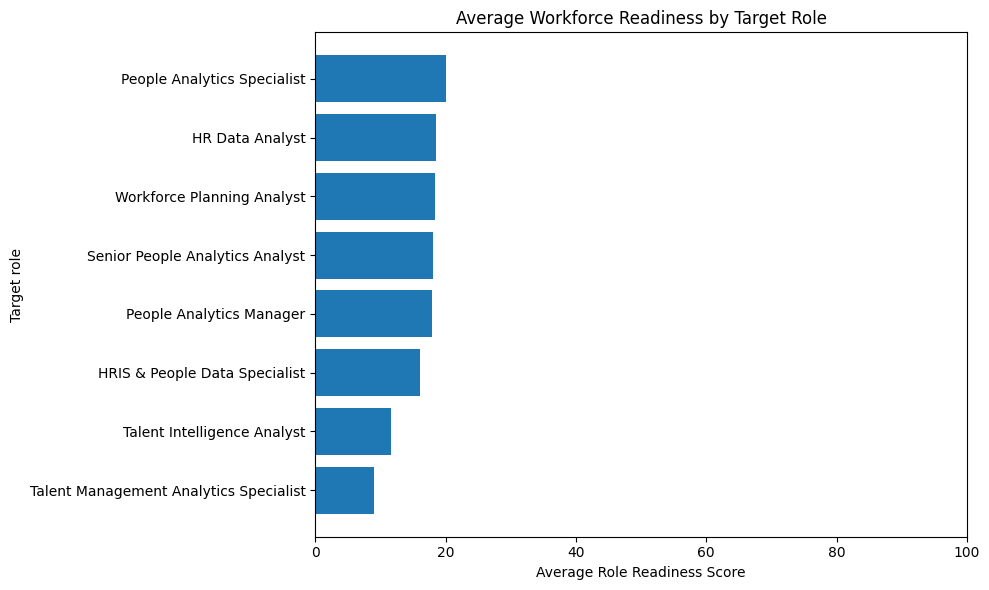

In [10]:
plot_data = role_summary.sort_values('AvgReadiness')
plt.figure(figsize=(10,6))
plt.barh(plot_data['RoleName'], plot_data['AvgReadiness'])
plt.xlabel('Average Role Readiness Score')
plt.ylabel('Target role')
plt.title('Average Workforce Readiness by Target Role')
plt.xlim(0,100)
plt.tight_layout()
plt.show()


### 9. Organization-wide skill-gap priorities


In [11]:
candidate_keys = top_candidates[['EmployeeID','RoleID']].drop_duplicates()
candidate_gaps = comparison.merge(candidate_keys, on=['EmployeeID','RoleID'], how='inner')

skill_gap_priority = (
    candidate_gaps[candidate_gaps['SkillGap'] > 0]
    .groupby('Skill')
    .agg(
        CandidateGapOccurrences=('EmployeeID','count'),
        AvgGap=('SkillGap','mean'),
        MaxImportance=('ImportanceWeight','max'),
        RolesAffected=('RoleID','nunique')
    )
    .reset_index()
)

skill_gap_priority['PriorityIndex'] = (
    skill_gap_priority['CandidateGapOccurrences'] *
    skill_gap_priority['AvgGap'] *
    skill_gap_priority['MaxImportance']
)

skill_gap_priority = skill_gap_priority.sort_values('PriorityIndex', ascending=False)
skill_gap_priority.head(15).round(2)


,Skill,CandidateGapOccurrences,AvgGap,MaxImportance,RolesAffected,PriorityIndex
33,Workforce Analytics,30,4.33,3,3,390.0
17,People Analytics,40,2.90,3,6,348.0
19,Power BI,44,2.59,3,6,342.0
3,Data Governance,35,2.60,3,4,273.0
29,Talent Analytics,25,3.12,3,3,234.0
34,Workforce Planning,18,3.72,3,2,201.0
14,Internal Mobility,20,3.25,3,2,195.0
7,Data Visualization,27,2.30,3,3,186.0
12,HR Data Management,14,4.36,3,2,183.0
5,Data Quality,26,2.31,3,3,180.0


### 10. Skill gaps by target role


In [12]:
role_skill_gaps = (
    candidate_gaps[candidate_gaps['SkillGap'] > 0]
    .groupby(['RoleID','RoleName','Skill'])
    .agg(
        CandidateGapOccurrences=('EmployeeID','count'),
        AvgGap=('SkillGap','mean'),
        RequiredProficiency=('RequiredProficiency','max'),
        ImportanceWeight=('ImportanceWeight','max')
    )
    .reset_index()
)

role_skill_gaps['PriorityIndex'] = (
    role_skill_gaps['CandidateGapOccurrences'] *
    role_skill_gaps['AvgGap'] *
    role_skill_gaps['ImportanceWeight']
)

role_skill_gaps = role_skill_gaps.sort_values(
    ['RoleID','PriorityIndex'], ascending=[True,False]
)

role_skill_gaps.head(30).round(2)


,RoleID,RoleName,Skill,CandidateGapOccurrences,AvgGap,RequiredProficiency,ImportanceWeight,PriorityIndex
3,R001,People Analytics Specialist,Data Visualization,10,2.70,4,3,81.0
11,R001,People Analytics Specialist,Turnover Analysis,10,3.00,3,2,60.0
0,R001,People Analytics Specialist,DAX,10,2.60,3,2,52.0
7,R001,People Analytics Specialist,Power BI,8,2.12,4,3,51.0
5,R001,People Analytics Specialist,Excel,10,2.10,4,2,42.0
6,R001,People Analytics Specialist,People Analytics,6,2.17,4,3,39.0
1,R001,People Analytics Specialist,Data Quality,7,2.71,3,2,38.0
8,R001,People Analytics Specialist,SQL,5,2.20,3,3,33.0
10,R001,People Analytics Specialist,Statistics,6,2.00,3,2,24.0
4,R001,People Analytics Specialist,Employee Engagement,7,3.00,3,1,21.0


### 11. Examine one candidate in detail


In [13]:
example = top_candidates.sort_values('RoleReadinessScore', ascending=False).iloc[0]
example_employee = example['EmployeeID']
example_role = example['RoleID']

print('Employee:', example_employee)
print('Target role:', example['RoleName'])
print('Readiness:', example['RoleReadinessScore'])

candidate_detail = comparison[
    (comparison['EmployeeID'] == example_employee) &
    (comparison['RoleID'] == example_role)
][[
    'Skill','ProficiencyLevel','RequiredProficiency','ImportanceWeight',
    'Mandatory','SkillGap','MeetsRequirement'
]].sort_values(['SkillGap','ImportanceWeight'], ascending=[False,False])

candidate_detail


Employee: E0111
Target role: Workforce Planning Analyst
Readiness: 60.7


,Skill,ProficiencyLevel,RequiredProficiency,ImportanceWeight,Mandatory,SkillGap,MeetsRequirement
9495,Workforce Planning,0.0,5,3,Yes,5.0,False
9501,Workforce Analytics,0.0,4,3,Yes,4.0,False
9496,Forecasting,3.0,4,3,Yes,1.0,False
9498,Excel,3.0,4,2,No,1.0,False
9500,Statistics,2.0,3,2,No,1.0,False
9497,Scenario Modeling,4.0,4,3,Yes,0.0,True
9499,Power BI,3.0,3,2,No,0.0,True
9502,Business Acumen,4.0,4,2,No,0.0,True
9503,Stakeholder Management,4.0,4,2,No,0.0,True
9504,Data Storytelling,4.0,3,2,No,0.0,True


### 12. Save analytical outputs


In [14]:
readiness.to_csv(OUTPUT_DIR / 'employee_role_readiness.csv', index=False)
top_candidates.to_csv(OUTPUT_DIR / 'top_internal_candidates.csv', index=False)
comparison.to_csv(OUTPUT_DIR / 'employee_role_skill_comparison.csv', index=False)
role_summary.to_csv(OUTPUT_DIR / 'role_readiness_summary.csv', index=False)
skill_gap_priority.to_csv(OUTPUT_DIR / 'skill_gap_priority.csv', index=False)
role_skill_gaps.to_csv(OUTPUT_DIR / 'role_skill_gaps.csv', index=False)

print('Saved:')
for f in [
    'employee_role_readiness.csv',
    'top_internal_candidates.csv',
    'employee_role_skill_comparison.csv',
    'role_readiness_summary.csv',
    'skill_gap_priority.csv',
    'role_skill_gaps.csv'
]:
    print('-', OUTPUT_DIR / f)


Saved:
- outputs/employee_role_readiness.csv
- outputs/top_internal_candidates.csv
- outputs/employee_role_skill_comparison.csv
- outputs/role_readiness_summary.csv
- outputs/skill_gap_priority.csv
- outputs/role_skill_gaps.csv


## Interpretation note
This model is a **portfolio analytics prototype**, not an automated employment decision system. A real implementation would require validated skills data, employee consent and transparency, governance, bias testing, human review, and organizational calibration of the scoring logic.

## Next phase
Notebook 03 will use NLP to extract skills from free-text job descriptions and compare the extracted skills with the manually structured role requirements.
